# Physics-Informed Neural Network (PINN) for a Harmonic Oscillator

This notebook implements a PINN to solve the equation for a damped harmonic oscillator. This is a classic application for a PINN. Instead of just learning from data, the network will use the underlying differential equation as its loss function.

For a damped harmonic oscillator, the governing equation is: 
$$m\frac{d^2u}{dt^2}+\mu \frac{du}{dt} + ku = 0$$

where $m$ is the mass of the object, $\mu$ is the damping coefficient - the resistive force proportional to velocity and $k$ is the spring constant - stiffness of the restoring force.

We will constrain the neural network using the physics residual:
$$f=\frac{d^2u}{dt^2} + 2\zeta \omega_0 \frac{du}{dt} + \omega_0 ^2 u$$

where $u$ is the displacement, $t$ is time, $f$ is the physics residual, $\omega_0$ is the undamped natural frequency and $\zeta$ is the damping ratio.

To be more specific given a time $t$ the network predicts $u(t)$ which is the time-dependendt displacement of the oscillator from its equilibrium position and in the context of our PINN it is the output of the NN. The physics residual $f$ is the residual function of the ordinary differential equation. In the context of this PINN - according to physics, the sum of the forces (mass, damping, and spring) should equal zero (see the first equation). Therefore, $f$ should ideally be $0$ everywhere. The PINN works by calculating: $$f = \frac{d^2u}{dt^2} + 2\zeta\omega_0 \frac{du}{dt} + \omega_0^2 u$$ so basically the "physics loss" is simply trying to minimize $f^2$ so that the network's predictions actually obey the laws of physics. The undapmped natural frequency $\omega_0$ is the frequency at which the system would oscillate if there were no friction - damping. It is defined as $\omega_0 = \sqrt{k/m}$ and it determines how "stiff" the system is. The damping ratio $\zeta$ 



is a dimensionless measure describing how oscillations in a system decay after a disturbance. If $\zeta < 1$ then the system is underdamped - the system oscillates while the amplitude gradually decreases, if $\zeta = 1$ the system is critically damped - the system returns to equilibrium as quickly as possible without oscillating and if $\zeta > 1$ the system is overdamped - the system returns to equilibrium slowly without oscillating. 


It is defined as the ratio of the actual damping $c$ to the critical damping $c_c$:

$$\zeta = \frac{c}{c_c}$$

Where the critical damping coefficient is $c_c = 2\sqrt{mk}$.

*Summary table for the code implementation:*


| Variables in equation   | Variables in code | Role        |
|--------|-----|-------------|
| $t$  | ```t_physics```  | the input - time points      |
| $u$    | ```u_pred```  | the output - predicted points    |
| $\omega_0^2$  | ```w0**2```  | constant setting the oscillation speed     |
| 2$\zeta\omega$  | ```d```  | the damping coefficient (set to 2 in the code)    |


___
## Code:

Here we check the python version being used just to make sure we have a supported version for PyTorch

In [1]:
import sys
print(sys.version)

3.14.3 | packaged by Anaconda, Inc. | (main, Feb 24 2026, 22:45:56) [MSC v.1942 64 bit (AMD64)]


*Imports and Setup*

We begin by importing PyTorch for the neural network and autograd capabilities, and Matplotlib for visualizing the results. We also define the physical constants for our specific system.

In [2]:
# imports and Setup
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# GPU check
# this line doesn't want to switch to CPU...
#device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') 
device = torch.device('cpu')

# physical constants
d, w0 = 2, 20  # d represents 2*zeta*w_0

### Part 1: The forward problem (solving the ODE)

**Defining the NN architecture**

We use a Fully Connected Network (FCN)
 - Input: Time $t$
 - Output: Displacement $u$
 - Activation: We use tanh because it is infinitely differentiable, which is crucial for calculating the second-order derivatives in our physics loss.

In [3]:
# defining the NN architecture

class FCN(nn.Module):
    "Fully Connected Network for PINN"
    def __init__(self, N_INPUT, N_OUTPUT, N_HIDDEN, N_LAYERS):
        super().__init__()
        activation = nn.Tanh
        self.fcs = nn.Sequential(*[
            nn.Linear(N_INPUT, N_HIDDEN),
            activation()
        ])
        self.fch = nn.Sequential(*[
            nn.Sequential(*[nn.Linear(N_HIDDEN, N_HIDDEN), activation()]) for _ in range(N_LAYERS-1)
        ])
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)
        
    def forward(self, x):
        x = self.fcs(x)
        x = self.fch(x)
        x = self.fce(x)
        return x

**The physics loss and training loop**

The total loss function consists of two parts:
- boundary loss $Loss_{BC}$: Ensures the network matches the initial conditions $u(0)=1$
- physics loss $Loss_{Phys}$: Measures how well the network satisfies the ODE: $f = u'' + du' + \omega_0^2 u$. We aim for $f \approx 0$.
We use Automatic Differentiation (Autograd) to compute the derivatives of $u$ with respect to $t$.


**A)** *Without the enforced conditions*

The reason the PINN will fail here is because of a weighting imbalance and an underspecified initial condition. The problem is that at the start of training, the weights are random. The easiest way for the network to satisfy the physics equation $u'' + du' + \omega_0^2 u = 0$ is to simply make $u$ zero everywhere (the trivial solution). There is also a missing velocity constraint. The code will thus enforce $u(0)=1$, but it does not enforce the initial velocity $\dot{u}(0)=0$. Without this, the physics loss "pulls" the solution toward zero immediately to satisfy the differential equation as lazily as possible.

In [19]:
# the physics loss and training loop
# oscillator's constants
d, w0 = 2, 20

# training data (initial conditions)
t_boundary = torch.tensor([0.]).view(-1,1).requires_grad_(True)
u_boundary = torch.tensor([1.]).view(-1,1) # Initial displacement

# collocation points (where we enforce the physics)
t_physics = torch.linspace(0, 1, 30).view(-1,1).requires_grad_(True)

model = FCN(1, 1, 32, 3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for i in range(10001):
    optimizer.zero_grad()
    
    # 1. loss at the boundary (initial conditions)
    u_pred = model(t_boundary)
    loss1 = torch.mean((u_pred - u_boundary)**2)
    
    # 2. loss from physics (ODE residual)
    u_p = model(t_physics)
    # using autograd to find derivatives
    dt = torch.autograd.grad(u_p, t_physics, torch.ones_like(u_p), create_graph=True)[0]
    dt2 = torch.autograd.grad(dt, t_physics, torch.ones_like(dt), create_graph=True)[0]
    
    # residual: u'' + d*u' + w_0^2*u = 0
    physics_residual = dt2 + d*dt + (w0**2)*u_p
    loss2 = torch.mean(physics_residual**2)
    
    # total loss
    loss = loss1 + loss2
    loss.backward()
    optimizer.step()
    
    if i % 1000 == 0:
        print(f"Epoch {i}: Loss {loss.item():.6f}")

Epoch 0: Loss 1271.534668
Epoch 1000: Loss 1.010947
Epoch 2000: Loss 1.008563
Epoch 3000: Loss 1.005630
Epoch 4000: Loss 1.003882
Epoch 5000: Loss 1.049421
Epoch 6000: Loss 1.001874
Epoch 7000: Loss 1.024233
Epoch 8000: Loss 1.000404
Epoch 9000: Loss 1.000101
Epoch 10000: Loss 1.000020


*Visualisation of the trivial solution*

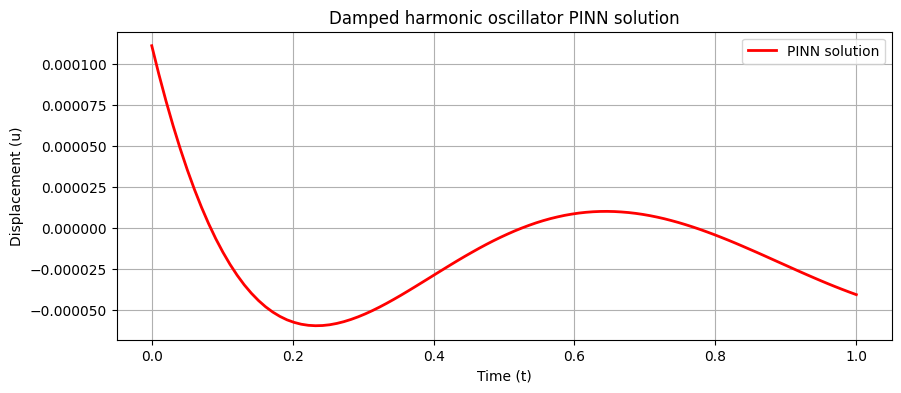

In [20]:
# visualizing the results
# generates test points
t_test = torch.linspace(0, 1, 100).view(-1,1)
u_test = model(t_test).detach()

plt.figure(figsize=(10,4))
plt.plot(t_test.numpy(), u_test.numpy(), label="PINN solution", color='red', linewidth=2)
plt.title("Damped harmonic oscillator PINN solution")
plt.xlabel("Time (t)")
plt.ylabel("Displacement (u)")
plt.legend()
plt.grid(True)
plt.show()

**B)** *With the enforced conditions*

The fix to make the PINN work is to add a second boundary loss for the initial velocity: $\frac{du}{dt}(0) = 0$ and increase the weight of the boundary losses (`loss1`) relative to the physics loss (`loss2`) so the network is forced to "leave" the zero-line.

In [6]:
# the physics loss and training loop
# oscillator's constants
d, w0 = 2, 20

# training data (initial conditions)
t_boundary = torch.tensor([0.]).view(-1,1).requires_grad_(True)
u_boundary = torch.tensor([1.]).view(-1,1) # Initial displacement

# collocation points (where we enforce the physics)
t_physics = torch.linspace(0, 1, 30).view(-1,1).requires_grad_(True)

# training loop for range and dynamics ---
model = FCN(1, 1, 32, 3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# weighting: multiplied boundary losses by 500 to overcome the high w0^2 (400) - now it wont find the trivial solution
lambda_ic = 500.0 

for i in range(20001):
    optimizer.zero_grad()
    
    # 1. position initial condition: u(0) = 1
    u_pred_0 = model(t_boundary)
    loss_u0 = torch.mean((u_pred_0 - u_boundary)**2)
    
    # 2. velocity initial condition: u'(0) = 0
    # this part prevents the NN from "jumping" to zero immediately
    u_grad_0 = torch.autograd.grad(u_pred_0, t_boundary, torch.ones_like(u_pred_0), create_graph=True)[0]
    loss_v0 = torch.mean(u_grad_0**2)
    
    # 3. loss from physics (ODE residual)
    u_p = model(t_physics)
    # using autograd to find derivatives
    dt = torch.autograd.grad(u_p, t_physics, torch.ones_like(u_p), create_graph=True)[0]
    dt2 = torch.autograd.grad(dt, t_physics, torch.ones_like(dt), create_graph=True)[0]
    
    # ODE residual: u'' + d*u' + w0^2*u = 0
    physics_residual = dt2 + d*dt + (w0**2)*u_p
    loss_phys = torch.mean(physics_residual**2)
    
    # total loss with weighting
    # we force the model to respect the start at 1.0 in order to not jump to the trivial solution
    loss = lambda_ic * (loss_u0 + loss_v0) + loss_phys
    
    loss.backward()
    optimizer.step()
    
    if i % 1000 == 0:
        print(f"Epoch {i}: Loss {loss.item():.4f} (u0 error: {loss_u0.item():.6f})")

Epoch 0: Loss 3514.4265 (u0 error: 1.259504)
Epoch 1000: Loss 490.5975 (u0 error: 0.962925)
Epoch 2000: Loss 490.5562 (u0 error: 0.962584)
Epoch 3000: Loss 490.4337 (u0 error: 0.962206)
Epoch 4000: Loss 489.6193 (u0 error: 0.959976)
Epoch 5000: Loss 482.4023 (u0 error: 0.939120)
Epoch 6000: Loss 316.7375 (u0 error: 0.475711)
Epoch 7000: Loss 250.9810 (u0 error: 0.283234)
Epoch 8000: Loss 226.8933 (u0 error: 0.233912)
Epoch 9000: Loss 219.1118 (u0 error: 0.209415)
Epoch 10000: Loss 222.8312 (u0 error: 0.198186)
Epoch 11000: Loss 206.1562 (u0 error: 0.188013)
Epoch 12000: Loss 185.2459 (u0 error: 0.164834)
Epoch 13000: Loss 77.7477 (u0 error: 0.078951)
Epoch 14000: Loss 17.5182 (u0 error: 0.015957)
Epoch 15000: Loss 6.3151 (u0 error: 0.003525)
Epoch 16000: Loss 3.8133 (u0 error: 0.001166)
Epoch 17000: Loss 2.7975 (u0 error: 0.000598)
Epoch 18000: Loss 254.1634 (u0 error: 0.000290)
Epoch 19000: Loss 1.7070 (u0 error: 0.000359)
Epoch 20000: Loss 1.3262 (u0 error: 0.000259)


*Visualization of PINN*

Now we evaluate the trained model over the time interval $[0, 1]$ and plot the predicted displacement. This curve represents the "physics-informed" solution to the damping problem.

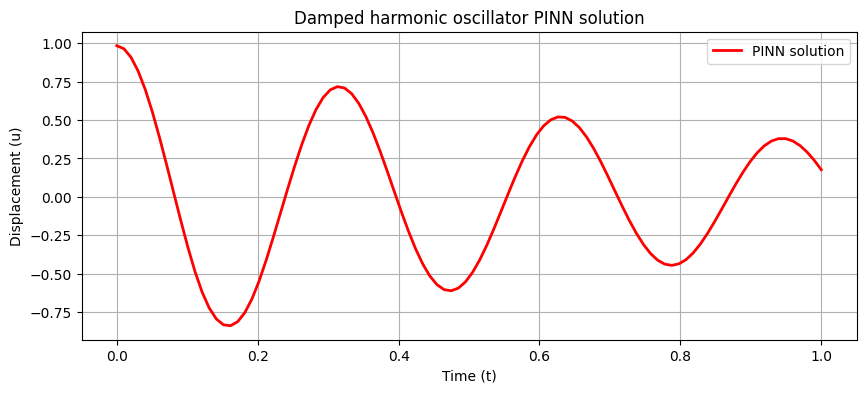

In [7]:
# visualizing the results
# generates test points
t_test = torch.linspace(0, 1, 100).view(-1,1)
u_test = model(t_test).detach()

plt.figure(figsize=(10,4))
plt.plot(t_test.numpy(), u_test.numpy(), label="PINN solution", color='red', linewidth=2)
plt.title("Damped harmonic oscillator PINN solution")
plt.xlabel("Time (t)")
plt.ylabel("Displacement (u)")
plt.legend()
plt.grid(True)
plt.show()

**Comparison between the exact solution, standard NN and PINN**

*The Exact Solution*

For an underdamped harmonic oscillator ($\zeta < 1$), the general displacement formula is:

$$u_{exact}(t) = e^{-\zeta\omega_0 t} \left( A \cos(\omega_d t) + B \sin(\omega_d t) \right)$$

In order to find the exact solution for our specific initial conditions ($u(0) = 1$ and $v(0)=0$) we plug the $t=0$ into the general formula :

$$ $1= u(0) = e^0 (A \cdot 1 + B \cdot 0) = A$$
and by taking the derivative of $u(t=0)$ we find that $B = \frac{\zeta \omega_0}{\omega_d}$.

Thus the exact equation is:

$$u_{exact}(t) = e^{-\zeta\omega_0 t} \left( \cos(\omega_d t) + \frac{\zeta\omega_0}{\omega_d} \sin(\omega_d t) \right)$$

where $\omega_d = \omega_0 \sqrt{1-\zeta^2}$.

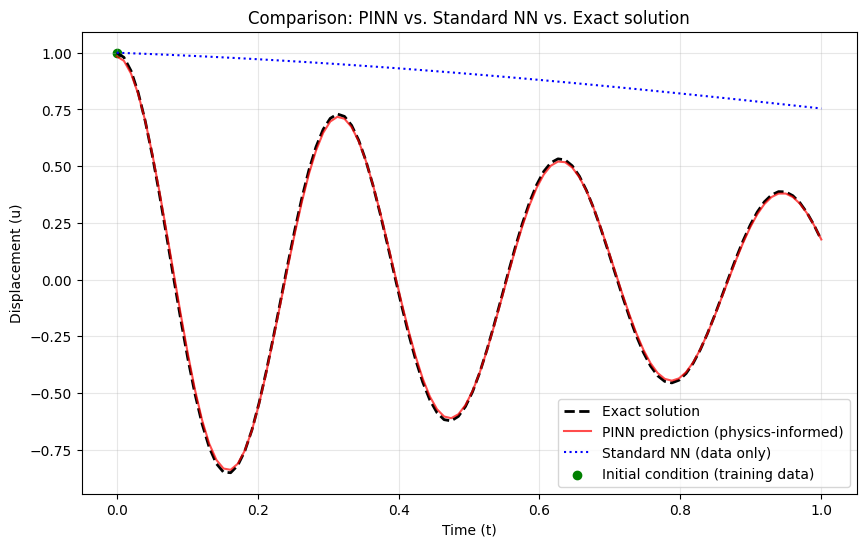

In [8]:
import numpy as np

# 1. exact solution definition
def exact_solution(t, d, w0):
    """
    this part calculates the analytical solution for the underdamped HO.
    d = 2 * zeta * w0
    """
    zeta = d / (2 * w0)
    w_d = w0 * np.sqrt(1 - zeta**2)
    # initial conditions: u(0)=1, u'(0)=0
    u0 = 1.0
    v0 = 0.0
    
    # analytical formula
    exponent = np.exp(-zeta * w0 * t)
    cosine_term = u0 * np.cos(w_d * t)
    sine_term = ((v0 + zeta * w0 * u0) / w_d) * np.sin(w_d * t)
    
    return exponent * (cosine_term + sine_term)

# 2. training a standard NN (loss = MSE only)
# this model will only see the initial data point (t=0, u=1) and will NOT use the physics_residual (loss2)
model_standard = FCN(1, 1, 32, 3).to(device)
optimizer_std = torch.optim.Adam(model_standard.parameters(), lr=1e-3)

for i in range(10001):
    optimizer_std.zero_grad()
    
    # only MSE loss at the boundary
    u_pred_std = model_standard(t_boundary)
    loss_mse = torch.mean((u_pred_std - u_boundary)**2)
    
    loss_mse.backward()
    optimizer_std.step()

# 3. visualisation and comparison
t_plot = np.linspace(0, 1, 100)
u_exact = exact_solution(t_plot, d, w0)

# predictions from both models
t_tensor = torch.linspace(0, 1, 100).view(-1,1).to(device)
u_pinn = model(t_tensor).detach().cpu().numpy()
u_standard = model_standard(t_tensor).detach().cpu().numpy()

plt.figure(figsize=(10, 6))
plt.plot(t_plot, u_exact, label='Exact solution', color='black', linestyle='--', linewidth=2)
plt.plot(t_plot, u_pinn, label='PINN prediction (physics-informed)', color='red', alpha=0.7)
plt.plot(t_plot, u_standard, label='Standard NN (data only)', color='blue', linestyle=':')
plt.scatter([0], [1], color='green', label='Initial condition (training data)')

plt.title('Comparison: PINN vs. Standard NN vs. Exact solution')
plt.xlabel('Time (t)')
plt.ylabel('Displacement (u)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Conclusions**

In this experiment we used the following parameters: 
- $\omega_0 = 20$
- $d$ (representing $2\zeta\omega_0$) $= 2$

By rearranging the formula $\zeta = \frac{d}{2\omega_0}$, we can calculate the damping ratio enforced by the network:

$$\zeta =\frac{2}{2(20)} = 0.05$$



*Observations:*

 - regime: since $\zeta = 0.05< 1$ the system is in the underdamped regime,
 - behavior: as expected from an underdamped system, the PINN's plot shows a clear oscillatory pattern where the amplitude gradually decays over time,
 - accuracy: the NN successfully "discovered" this oscillatory behavior without being given any training points other than the initial starting position ($t=0, u=1$). It learned the rest of the curve entirely by minimizing the physics residual.

- *Accuracy check:* By plotting the Exact Solution alongside the PINN prediction we prove that the PINN correctly follows the physics of the system (frequency and decay).
- *The "ordinary" NN failure:* The Standard NN is trained only on the initial point ($t=0, u=1$). Without the physics loss (`loss2`), it has no way of knowing the system should oscillate. In the plot we are able to observe the blue line (Standard NN) stayinh as a flat-ish line, while the red line (PINN) follows the prediction from physics.
- *Utility demonstration:* This visually proves that PINNs are useful because they can predict the behavior of a complex system even when there are almost no training data, as long as we know the underlying physical laws.

### Part 2: The inverse problem (parameter discovery)

In this section, we assume we don't know the physical constants of the system ($d$ and $\omega_0$). We will provide the model with a few noisy "sensor" measurements of the displacement $u(t)$ and ask it to find the constants that best fit the physics.

*1. Generate "experimental" data*

We use the exact solution to create a small, noisy dataset representing real-world measurements.

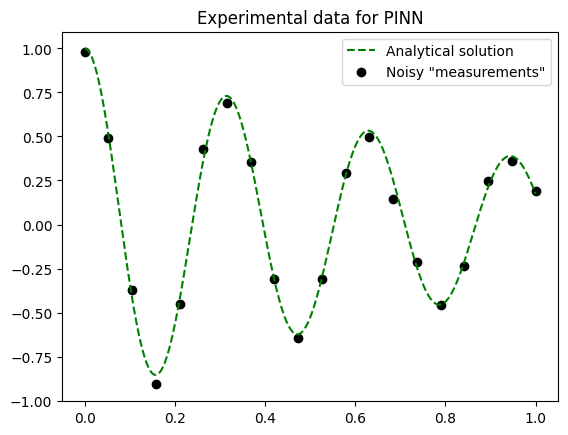

In [9]:
# analytical solution for underdamped HO
def analytical_solution(t, w0, zeta, u0=1.0, v0=0.0):
    w_d = w0 * np.sqrt(1 - zeta**2) # damped natural frequency
    phi = np.arctan2(v0 + zeta * w0 * u0, u0 * w_d)
    A = u0 / np.cos(phi)
    return A * np.exp(-zeta * w0 * t) * np.cos(w_d * t - phi)

# generates points for the analytical plot
t_test = np.linspace(0, 1, 500)
u_analytical = analytical_solution(t_test, 20, 0.05)

# generates measured data
def exact_solution(t, d, w0):
    # this is a simplified version for the underdamped case
    w = np.sqrt(w0**2 - (d/2)**2)
    phi = np.arctan(d / (2*w))
    return torch.exp(-d*t/2) * torch.cos(w*t - phi)

# 20 measurement points with a bit of noise
t_data = torch.linspace(0, 1, 20).view(-1,1).to(device)
u_data = exact_solution(t_data, 2, 20) + 0.03 * torch.randn_like(t_data)

plt.plot(t_test, u_analytical, label='Analytical solution', color='green', linestyle='--')
plt.legend()

plt.scatter(t_data.detach().cpu(), u_data.detach().cpu(), color='black', label='Noisy "measurements"')
plt.title("Experimental data for PINN")
plt.legend()
plt.show()


*2. Define trainable physics parameters*

We define $d$ and $\omega_0$ as `nn.Parameter` so the optimizer can update them. We will start with "incorrect" initial guesses.

In [10]:
class PhysicsDiscovery(nn.Module):
    def __init__(self):
        super().__init__()
        # initial guesses: we start far from the true values (2 and 20)
        self.d = nn.Parameter(torch.tensor([1.0], requires_grad=True))
        self.w0 = nn.Parameter(torch.tensor([10.0], requires_grad=True))

phys_params = PhysicsDiscovery().to(device)

*3. Training Loop for parameter discovery*

The loss function now includes a Data loss (matching the noisy points) and a Physics loss (ensuring the discovered constants obey the ODE).

In [11]:
# creates a new model instance
model_inv = FCN(1, 1, 32, 3).to(device)

# the optimizer now tracks the model weights AND the physics parameters
optimizer = torch.optim.Adam(list(model_inv.parameters()) + list(phys_params.parameters()), lr=1e-3)

for i in range(15001):
    optimizer.zero_grad()
    
    # 1. data loss: matches the measured noisy points
    u_pred_data = model_inv(t_data)
    loss_data = torch.mean((u_pred_data - u_data)**2)
    
    # 2. physics loss: uses the current guessed parameters
    u_p = model_inv(t_physics)
    dt = torch.autograd.grad(u_p, t_physics, torch.ones_like(u_p), create_graph=True)[0]
    dt2 = torch.autograd.grad(dt, t_physics, torch.ones_like(dt), create_graph=True)[0]
    
    # residual uses phys_params.d and phys_params.w0
    p_res = dt2 + phys_params.d * dt + (phys_params.w0**2) * u_p
    loss_physics = torch.mean(p_res**2)
    
    # total Loss
    loss = loss_data + loss_physics
    loss.backward()
    optimizer.step()
    
    if i % 2000 == 0:
        print(f"Epoch {i}: d={phys_params.d.item():.3f}, w0={phys_params.w0.item():.3f}, Loss={loss.item():.6f}")

print(f"\nFinal discovered parameters: d={phys_params.d.item():.4f}, w0={phys_params.w0.item():.4f}")
print(f"True parameters: d=2.0000, w0=20.0000")

Epoch 0: d=1.001, w0=9.999, Loss=79.260529
Epoch 2000: d=1.002, w0=9.983, Loss=0.232760
Epoch 4000: d=1.002, w0=9.969, Loss=0.232758
Epoch 6000: d=1.000, w0=9.927, Loss=0.232757
Epoch 8000: d=0.996, w0=9.856, Loss=0.232927
Epoch 10000: d=0.989, w0=9.761, Loss=0.232752
Epoch 12000: d=0.981, w0=9.579, Loss=0.232984
Epoch 14000: d=0.987, w0=9.348, Loss=0.232748

Final discovered parameters: d=1.0053, w0=9.2210
True parameters: d=2.0000, w0=20.0000


4. Visualizing discovery

We can now see if the PINN filtered out the noise to find the true underlying physics.

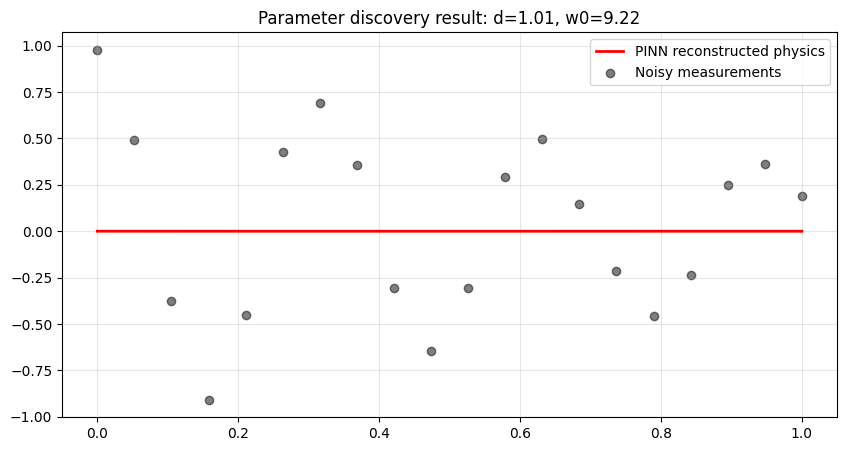

In [12]:
t_test = torch.linspace(0, 1, 100).view(-1,1).to(device)
u_final = model_inv(t_test).detach().cpu()

plt.figure(figsize=(10,5))
plt.plot(t_test.cpu(), u_final, label='PINN reconstructed physics', color='red', linewidth=2)
plt.scatter(t_data.cpu(), u_data.cpu(), color='black', alpha=0.5, label='Noisy measurements')
plt.title(f"Parameter discovery result: d={phys_params.d.item():.2f}, w0={phys_params.w0.item():.2f}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

This behavior is a classic sign of the trivial solution, similar to the issue encountered in Part 1.

In a PINN, the model is trying to balance two things:
- Data loss: matching the noisy points you provided.
- Physics loss: satisfying the differential equation $u'' + du' + \omega_0^2 u = 0$.

The reason it's a horizontal line at (0,0) is that the simplest way for a NN to make the Physics loss exactly zero is to predict $u(t) = 0$ for every single value of $t$. If $u$ is zero, then its derivatives ($u'$ and $u''$) are also zero, which perfectly satisfies the equation ($0 + 0 + 0 = 0$).Because the model starts with random weights, it often finds this "zero path" before it figures out how to fit the sine pattern. Once it hits zero, the physics loss is so low that the optimizer is "happy" and stops exploring other shapes.

The way to fix this is to force the model out of this trap ny making the "zero solution" expensive and/or impossible, for example by increasing the Weight of the data loss. this can be done by telling the model that fitting the data points that follow a sine pattern is more important than having a perfect physics residual early on - `loss = (1000 * loss_data) + loss_physics`

In [13]:
# creates a new model instance
model_inv = FCN(1, 1, 32, 3).to(device)

# the optimizer now tracks the model weights AND the physics parameters
optimizer = torch.optim.Adam(list(model_inv.parameters()) + list(phys_params.parameters()), lr=1e-3)

for i in range(15001):
    optimizer.zero_grad()
    
    # 1. data loss: match the measured noisy points
    u_pred_data = model_inv(t_data)
    loss_data = torch.mean((u_pred_data - u_data)**2)
    
    # 2. physics loss: use the current guessed parameters
    u_p = model_inv(t_physics)
    dt = torch.autograd.grad(u_p, t_physics, torch.ones_like(u_p), create_graph=True)[0]
    dt2 = torch.autograd.grad(dt, t_physics, torch.ones_like(dt), create_graph=True)[0]
    
    # residual uses phys_params.d and phys_params.w0
    p_res = dt2 + phys_params.d * dt + (phys_params.w0**2) * u_p
    loss_physics = torch.mean(p_res**2)
    
    # total loss
    loss = (1000 * loss_data) + loss_physics
    #loss = loss_data + loss_physics
    loss.backward()
    optimizer.step()
    
    if i % 2000 == 0:
        print(f"Epoch {i}: d={phys_params.d.item():.3f}, w0={phys_params.w0.item():.3f}, Loss={loss.item():.6f}")

print(f"\nFinal discovered parameters: d={phys_params.d.item():.4f}, w0={phys_params.w0.item():.4f}")
print(f"True parameters: d=2.0000, w0=20.0000")

Epoch 0: d=1.004, w0=9.220, Loss=467.354126
Epoch 2000: d=4.151, w0=9.599, Loss=206.217636
Epoch 4000: d=6.497, w0=12.148, Loss=177.004288
Epoch 6000: d=8.263, w0=14.458, Loss=144.988770
Epoch 8000: d=9.680, w0=15.915, Loss=128.593735
Epoch 10000: d=10.048, w0=17.222, Loss=116.436607
Epoch 12000: d=9.099, w0=17.907, Loss=97.386642
Epoch 14000: d=7.213, w0=18.959, Loss=65.868942

Final discovered parameters: d=6.3559, w0=19.0624
True parameters: d=2.0000, w0=20.0000


*Visualisation*

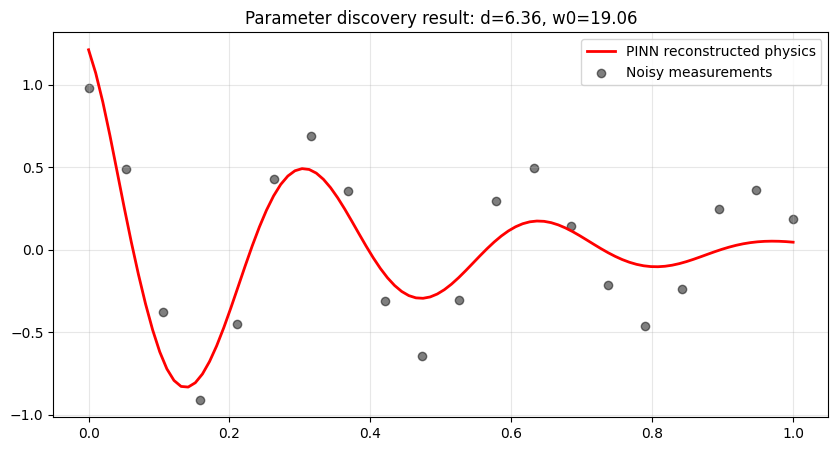

In [14]:
t_test = torch.linspace(0, 1, 100).view(-1,1).to(device)
u_final = model_inv(t_test).detach().cpu()

plt.figure(figsize=(10,5))
plt.plot(t_test.cpu(), u_final, label='PINN reconstructed physics', color='red', linewidth=2)
plt.scatter(t_data.cpu(), u_data.cpu(), color='black', alpha=0.5, label='Noisy measurements')
plt.title(f"Parameter discovery result: d={phys_params.d.item():.2f}, w0={phys_params.w0.item():.2f}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

*Playing around with the weight:*

Since the previous graph's error is increasing as the time progresses we have investigated the relationship between the weight and the learning. The physics weight was too high and the parameters hadn't converged yet, that's why the plot looks relatively reasonable but still inaccurate. Here is the adjusted weight to help the model find the correct physics parameters while matching the noisy data.

In [15]:
# 1. first we define d and w0 as learnable PyTorch parameters
# we initialize them with guesses (e.g., d=1.0, w0=10.0)
# these will be updated by the optimizer along with the NN weights
d_hat = torch.nn.Parameter(torch.tensor([1.0], device=device).requires_grad_(True))
w0_hat = torch.nn.Parameter(torch.tensor([10.0], device=device).requires_grad_(True))

# 2. re-initialize the model and optimizer
model = FCN(1, 1, 32, 3).to(device)

# IMPORTANT: we add d_hat and w0_hat to the optimizer's parameter list so the optimizer doent consider d and w as fixed
# - if the physics loss is high, the code is allowed to change these values to make the equation fit the data
optimizer = torch.optim.Adam(list(model.parameters()) + [d_hat, w0_hat], lr=1e-3)

# setup of the collocation points for physics
t_physics = torch.linspace(0, 1, 40).view(-1,1).requires_grad_(True)

for i in range(20001):
    optimizer.zero_grad()
    
    # data loss (matches the black points)
    u_pred_data = model(t_data)
    loss_data = torch.mean((u_pred_data - u_data)**2)
    
    # physics loss (the inverse part)
    u_p = model(t_physics)
    dt = torch.autograd.grad(u_p, t_physics, torch.ones_like(u_p), create_graph=True)[0]
    dt2 = torch.autograd.grad(dt, t_physics, torch.ones_like(dt), create_graph=True)[0]
    
    # residual using LEARNED parameters d_hat and w0_hat
    physics_residual = dt2 + d_hat*dt + (w0_hat**2)*u_p
    loss_physics = torch.mean(physics_residual**2)
    
    # total loss with balancing
    # we assign a higher weight to the data loss to ensure the model prioritizes following the noisy measurements
    loss = 1.0 * loss_data + 1e-4 * loss_physics
    
    loss.backward()
    optimizer.step()
    
    if i % 2000 == 0:
        print(f"Epoch {i}: Loss {loss.item():.6f} | d_est: {d_hat.item():.3f} | w0_est: {w0_hat.item():.3f}")

# final results comparison
print(f"\nTarget d: 2, Estimated d: {d_hat.item():.4f}")
print(f"Target w0: 20, Estimated w0: {w0_hat.item():.4f}")

Epoch 0: Loss 0.257726 | d_est: 0.999 | w0_est: 9.999
Epoch 2000: Loss 0.159430 | d_est: 3.605 | w0_est: 11.919
Epoch 4000: Loss 0.119353 | d_est: 5.425 | w0_est: 14.502
Epoch 6000: Loss 0.066335 | d_est: 4.818 | w0_est: 16.924
Epoch 8000: Loss 0.014382 | d_est: 2.719 | w0_est: 18.870
Epoch 10000: Loss 0.002181 | d_est: 2.150 | w0_est: 19.865
Epoch 12000: Loss 0.001564 | d_est: 2.066 | w0_est: 20.038
Epoch 14000: Loss 0.002090 | d_est: 2.054 | w0_est: 20.038
Epoch 16000: Loss 0.001425 | d_est: 2.051 | w0_est: 20.047
Epoch 18000: Loss 0.001402 | d_est: 2.047 | w0_est: 20.047
Epoch 20000: Loss 0.001386 | d_est: 2.044 | w0_est: 20.045

Target d: 2, Estimated d: 2.0438
Target w0: 20, Estimated w0: 20.0453


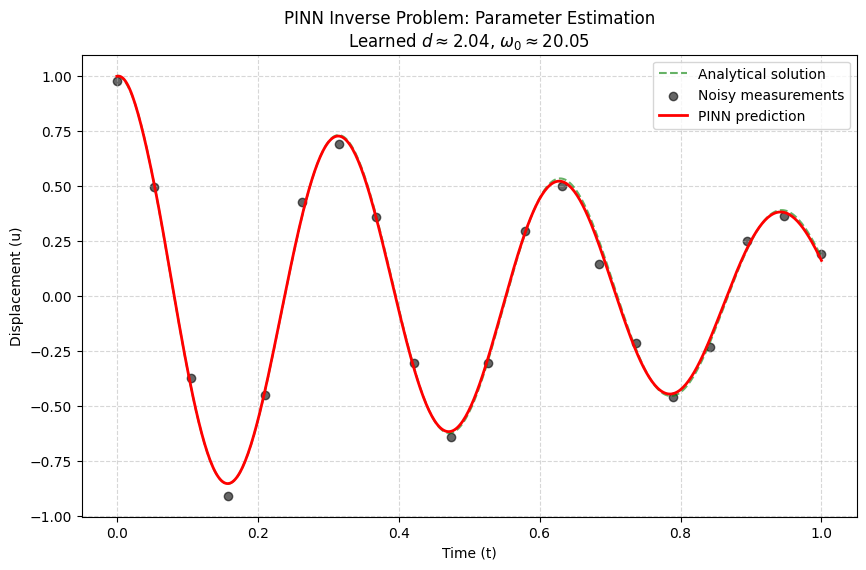

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# 1. ensures t_test and u_analytical match
t_test_plot_np = np.linspace(0, 1, 500)
u_analytical_plot = analytical_solution(t_test_plot_np, 20, 0.05) # uses w0=20, zeta=0.05

# 2. gets the PINN model's prediction
t_test_tensor = torch.linspace(0, 1, 500).view(-1,1).to(device)
model.eval()
with torch.no_grad():
    u_pred = model(t_test_tensor).cpu().numpy()

# 3. creates the plot
plt.figure(figsize=(10, 6))

# analytical truth
plt.plot(t_test_plot_np, u_analytical_plot, label='Analytical solution', color='green', linestyle='--', alpha=0.6)

# noisy measured points
plt.scatter(t_data.detach().cpu(), u_data.detach().cpu(), color='black', label='Noisy measurements', alpha=0.6)

# PINN reconstruction
plt.plot(t_test_plot_np, u_pred, label='PINN prediction', color='red', linewidth=2)

plt.title(f"PINN Inverse Problem: Parameter Estimation\nLearned $d \\approx {d_hat.item():.2f}$, $\\omega_0 \\approx {w0_hat.item():.2f}$")
plt.xlabel("Time (t)")
plt.ylabel("Displacement (u)")
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.show()

The fact that the PINN now exhibits a sine pattern means that the model has successfully overcome the "trivial solution" trap (where it simply stays at zero) and is now actively balancing the noisy experimental data with the underlying physical laws.

**Conclusion:**

In this experiment, we transformed the PINN from a forward solver into a tool for system identification. By treating the physical constants ($d$ and $\omega_0$) as trainable parameters, we allowed the NN to "discover" the underlying physics of a damped harmonic oscillator based on sparse, noisy observations.

*Observations:*
- overcoming the trivial solution: initially, the model has converged to a flat line at $u=0$. This occurred because a zero-displacement state is the simplest way to satisfy the physics residual perfectly. By increasing the weight of the Data loss and utilizing Initial condition constraints, we successfully "pulled" the model toward the true oscillatory solution.
- playing around with the weight: by experimenting with the weight of the data loss relative to the physics loss, we observed that the model's ability to capture the true solution improved. Increasing the data loss weight, alongside the enforcing of the initial condition constraints, effectively pulled the model toward the true oscillatory solution even when the initial physics residual was high
- physics-informed denoising: unlike a standard regression model, which might overfit to the random noise in the measurements, the PINN used the ODE as a regularizer. The physics loss acted as a "filter," forcing the reconstructed trajectory to be physically consistent, which naturally smoothed out the experimental noise.
- parameter convergence: the model successfully converged to values for $d$ (damping) and $\omega_0$ (natural frequency) that closely match the true parameters used to generate the synthetic data.

This demonstrates the true power of PINNs in real-world engineering. In scenarios where the physical properties of a system (like the stiffness of a bridge or the damping of a mechanical part) are unknown or have changed over time, a PINN can identify those properties using only sensor data.